# GCN vs. Skip-GNN con datos reales: elección presidencial en Colombia por municipio

Modelo: predecir si Duque ganó la elección presidencial en cada municipio de Colombia, usando:

- **36 variables municipales** (educación, salud, servicios públicos, criminalidad, presencia de grupos armados, alineación política del alcalde)
- **Una red geográfica real**: municipios que comparten frontera, construida a partir de un shapefile oficial del DANE (Marco Geoestadístico Nacional)
```

---
## Paso 1: cargar y explorar los datos reales

### ¿Qué tenemos?

- **Unidad de análisis**: municipio (identificado por su código DANE)
- **Variable dependiente (Y)**: `DUQUE_win` — 1 si Duque ganó la elección presidencial en ese municipio, 0 si no
- **36 variables predictoras (X)**, todas binarias, agrupadas en: ruralidad, educación, salud, servicios públicos, criminalidad, demografía, presencia de grupos armados, y alineación política del alcalde en funciones


In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

df = pd.read_csv('/Users/ykath/OneDrive - Universidad de los Andes/Escritorio/Instructora/20261/Grupos armados/Datos consolidados/BD_binarias3.csv')
print(f"Municipios: {df.shape[0]}, Columnas: {df.shape[1]}")
print(f"\nValores nulos: {df.isna().sum().sum()}")

# La variable dependiente
print(f"\nBalance de clases de DUQUE_win:")
print(df['DUQUE_win'].value_counts(normalize=True).rename('proporción'))

df.head()

Municipios: 965, Columnas: 38

Valores nulos: 0

Balance de clases de DUQUE_win:
DUQUE_win
1    0.78342
0    0.21658
Name: proporción, dtype: float64


,codigo,Rural,Ciudades,Cobertura media neta_Bajo,Cobertura media neta_Alto,SABER 11 (LyM)_Bajo,SABER 11 (LyM)_Alto,Cobertura Transición_Bajo,Cobertura Transición_Alto,Cobertura salud_Bajo,...,Densidad poblacional_Alto,ACSN,AGC ahora EGC,Disidencias de las FARC,ELN,EPL,Otras organizaciones,DUQUE_win,Apoyo_Duque,Apoyo_Petro
0,5001,0,1,0,1,0,1,0,1,0,...,1,0.0,0.0,0.0,0.0,0.0,0.0,1,1.0,0.0
1,5002,1,0,0,0,0,0,1,0,0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,1,1.0,0.0
2,5004,1,0,0,1,1,0,0,1,0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,1,1.0,0.0
3,5021,1,0,1,0,0,1,0,1,0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,1,0.0,0.0
4,5030,0,0,0,0,0,0,1,0,0,...,1,0.0,0.0,0.0,0.0,0.0,0.0,1,1.0,0.0


**Nota importante sobre el desbalance:** el 78% de los municipios votaron por Duque y solo el 22% no. Este desbalance es muy similar al que reporta el paper para su caso de estudio de elecciones en EE.UU. (85%/15%). Cuando hay este nivel de desbalance, la **accuracy simple puede ser engañosa** — un modelo que siempre predice "Duque gana" acertaría el 78% de las veces sin haber aprendido nada útil. Por eso, igual que en el paper, vamos a usar **balanced accuracy** (el promedio entre sensibilidad y especificidad) como métrica principal.

In [3]:
# Separamos las columnas: identificador, variable dependiente, y las 36 predictoras
feature_cols = [c for c in df.columns if c not in ['codigo', 'DUQUE_win']]
print(f"Número de variables predictoras (X): {len(feature_cols)}")
print(feature_cols)

Número de variables predictoras (X): 36
['Rural', 'Ciudades', 'Cobertura media neta_Bajo', 'Cobertura media neta_Alto', 'SABER 11 (LyM)_Bajo', 'SABER 11 (LyM)_Alto', 'Cobertura Transición_Bajo', 'Cobertura Transición_Alto', 'Cobertura salud_Bajo', 'Cobertura salud_Alto', 'Mortalidad Infantil_Bajo', 'Mortalidad Infantil_Alto', 'Cobertura eléctrica rural_Bajo', 'Cobertura eléctrica rural_Alto', 'Cobertura internet_Bajo', 'Cobertura internet_Alto', 'Cobertura Acueducto_Bajo', 'Cobertura Acueducto_Alto', 'Cobertura Alcantarillado_Bajo', 'Cobertura Alcantarillado_Alto', 'Hurtos x 10000 hab_Bajo', 'Hurtos x 10000 hab_Alto', 'Homicidios x 10000 hab_Bajo', 'Homicidios x 10000 hab_Alto', 'Violencia Intrafamiliar x 10000 hab_Bajo', 'Violencia Intrafamiliar x 10000 hab_Alto', 'Densidad poblacional_Bajo', 'Densidad poblacional_Alto', 'ACSN', 'AGC ahora EGC', 'Disidencias de las FARC', 'ELN', 'EPL', 'Otras organizaciones', 'Apoyo_Duque', 'Apoyo_Petro']


In [4]:
X_raw = df[feature_cols].values.astype(np.float32)
y_raw = df['DUQUE_win'].values.astype(np.float32)
codigos = df['codigo'].values

x = torch.tensor(X_raw)
y = torch.tensor(y_raw)

print(f"x (features): {x.shape}")
print(f"y (etiquetas): {y.shape}")

x (features): torch.Size([965, 36])
y (etiquetas): torch.Size([965])


---
## Paso 2: cargar la red geográfica real

1. Partimos de un shapefile oficial del DANE (`MGN_MPIO_POLITICO`) con los polígonos de los 1,121 municipios de Colombia
2. Filtramos a los 965 municipios que están en nuestro dataset
3. Para cada par de municipios, verificamos si sus polígonos **comparten frontera** (usando la operación geométrica `intersects` de la librería `shapely`, con un pequeño margen de tolerancia para cerrar micro-espacios de digitalización entre polígonos oficiales)
4. Cada par de municipios vecinos se guardó como una fila en `edges_geograficos.csv`

El resultado: **2,487 conexiones** entre municipios vecinos, con un promedio de ~5 vecinos por municipio. Solo 4 municipios quedaron sin ningún vecino en la red — no por error en el cálculo, sino porque sus vecinos geográficos reales (verificado contra el shapefile completo) simplemente no forman parte de los 965 municipios de este dataset.

In [5]:
edges_df = pd.read_csv(r"C:\Users\ykath\Downloads\edges_geograficos.csv")
print(f"Pares de municipios vecinos: {len(edges_df)}")
edges_df.head()

Pares de municipios vecinos: 2487


,municipio_origen,municipio_destino
0,97001,97161
1,97161,95200
2,97161,95025
3,5001,5036
4,5001,5380


In [ ]:
# Convertimos los códigos DANE de las aristas a índices de posición (0 a 964),
# que es lo que PyTorch Geometric espera en edge_index (no los códigos originales).
codigo_to_idx = {c: i for i, c in enumerate(codigos)}

src = edges_df['municipio_origen'].map(codigo_to_idx).values
dst = edges_df['municipio_destino'].map(codigo_to_idx).values

# Como el grafo es no dirigido, incluimos cada arista en ambos sentidos
edge_index = torch.tensor(
    np.vstack([np.concatenate([src, dst]), np.concatenate([dst, src])]),
    dtype=torch.long
)

print(f"edge_index: {edge_index.shape}  (el doble de 2,487 por incluir ambos sentidos)")

# Verificación rápida: ¿cuántos vecinos tiene, en promedio, cada municipio?
grados = torch.bincount(edge_index[0], minlength=len(df))
print(f"Grado promedio: {grados.float().mean():.2f}")
print(f"Municipios sin ningún vecino: {(grados == 0).sum().item()}") #(Tarairá, Norosí, Nuquí, Puerto Santander)

edge_index: torch.Size([2, 4974])  (el doble de 2,487 por incluir ambos sentidos)
Grado promedio: 5.15
Municipios sin ningún vecino: 4


In [ ]:
from torch_geometric.data import Data

data = Data(x=x, edge_index=edge_index, y=y)
print(data)

# División train/test (80/20)
n = len(df)
n_train = int(0.8 * n)
perm = torch.randperm(n)
train_idx, test_idx = perm[:n_train], perm[n_train:]

# Peso para compensar el desbalance de clases en la función de pérdida
# (igual que el paper, que menciona explícitamente usar cross-entropy ponderada)
pos_weight = torch.tensor([
    (y[train_idx] == 0).sum().item() / (y[train_idx] == 1).sum().item()
])
print(f"\npos_weight (para compensar el desbalance): {pos_weight.item():.3f}")
# pos_weight multiplica el error de la clase positiva (1) en la función de pérdida, para que tenga menos peso y el modelo no se sesgue hacia la clase mayoritaria.

Data(x=[965, 36], edge_index=[2, 4974], y=[965])

pos_weight (para compensar el desbalance): 0.266


---
## Paso 3: modelo baseline — regresión logística

Antes de entrenar los GNNs, entrenamos el mismo baseline que usa el paper: un **logit estándar**, que ignora por completo la red geográfica y solo usa los atributos propios de cada municipio.

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score

logit = LogisticRegression(max_iter=2000, class_weight='balanced')
logit.fit(X_raw[train_idx.numpy()], y_raw[train_idx.numpy()])

pred_logit = logit.predict(X_raw[test_idx.numpy()])
acc_logit = balanced_accuracy_score(y_raw[test_idx.numpy()], pred_logit)

print(f"Balanced accuracy - Regresión logística (sin red): {acc_logit:.3f}")

Balanced accuracy - Regresión logística (sin red): 0.745


---
## Paso 4: GCN normal vs. Skip-GNN

Usamos las mismas dos arquitecturas del ejemplo sintético, con dos ajustes para datos reales:

1. **`pos_weight` en la función de pérdida**: para que el desbalance de clases (78%/22%) no haga que el modelo simplemente prediga siempre "Duque gana"
2. **Dropout**: con solo 965 municipios y 36 variables, el riesgo de sobreajuste es real. Agregamos dropout (apagar aleatoriamente un % de neuronas durante el entrenamiento) para que el modelo generalice mejor, en vez de memorizar el conjunto de entrenamiento

También ampliamos el Skip-GNN para que las capas de grafo trabajen con embeddings de varias dimensiones (`hidden_dim`) en vez de un solo número por nodo — permite que el modelo capture relaciones más ricas entre los vecinos, al costo de ya no poder leer un único coeficiente interpretable por variable (volvemos a esto en el Paso 5).

In [10]:
class GCNNormal(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, dropout=0.4):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.out = torch.nn.Linear(hidden_dim, 1)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.out(x).squeeze()  # logits (sin sigmoid; se aplica en la pérdida)

In [11]:
from torch_geometric.nn import GCNConv

class SkipGNN(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, n_layers=2, dropout=0.4):
        super().__init__()
        # --- Parte privada ---
        self.linear_part = torch.nn.Linear(in_dim, hidden_dim)
        self.nonlinear_part = torch.nn.Sequential(
            torch.nn.Linear(in_dim, hidden_dim), torch.nn.ReLU(), torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden_dim, hidden_dim)
        )
        self.bn = torch.nn.BatchNorm1d(hidden_dim)

        # --- Parte social ---
        self.gcn_layers = torch.nn.ModuleList(
            [GCNConv(hidden_dim, hidden_dim) for _ in range(n_layers)]
        )
        self.out = torch.nn.Linear(hidden_dim, 1)
        self.dropout = dropout

    def forward(self, x, edge_index):
        u_priv = self.linear_part(x) + self.bn(self.nonlinear_part(x))
        a = u_priv
        for gcn in self.gcn_layers:
            a = gcn(a, edge_index) + u_priv   # conexión de salto
            a = F.relu(a)
            a = F.dropout(a, p=self.dropout, training=self.training)
        return self.out(a).squeeze()

In [12]:
def entrenar(model, epochs=150, lr=0.005, weight_decay=5e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    historial = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(x, edge_index)
        loss = F.binary_cross_entropy_with_logits(
            logits[train_idx], y[train_idx], pos_weight=pos_weight
        )
        loss.backward()
        optimizer.step()
        historial.append(loss.item())

    model.eval()
    with torch.no_grad():
        logits_test = model(x, edge_index)[test_idx]
        pred_test = (torch.sigmoid(logits_test) > 0.5).float()

    acc = balanced_accuracy_score(y[test_idx].numpy(), pred_test.numpy())
    return acc, historial

torch.manual_seed(0)
gcn_normal = GCNNormal(in_dim=len(feature_cols), hidden_dim=16)
acc_gcn, loss_gcn = entrenar(gcn_normal)

torch.manual_seed(0)
skip_gnn = SkipGNN(in_dim=len(feature_cols), hidden_dim=16, n_layers=2)
acc_skip, loss_skip = entrenar(skip_gnn)

print(f"{'='*55}")
print(f"Balanced accuracy - Logit (sin red):        {acc_logit:.3f}")
print(f"Balanced accuracy - GCN normal:              {acc_gcn:.3f}")
print(f"Balanced accuracy - Skip-GNN:                {acc_skip:.3f}")

Balanced accuracy - Logit (sin red):        0.745
Balanced accuracy - GCN normal:              0.780
Balanced accuracy - Skip-GNN:                0.811


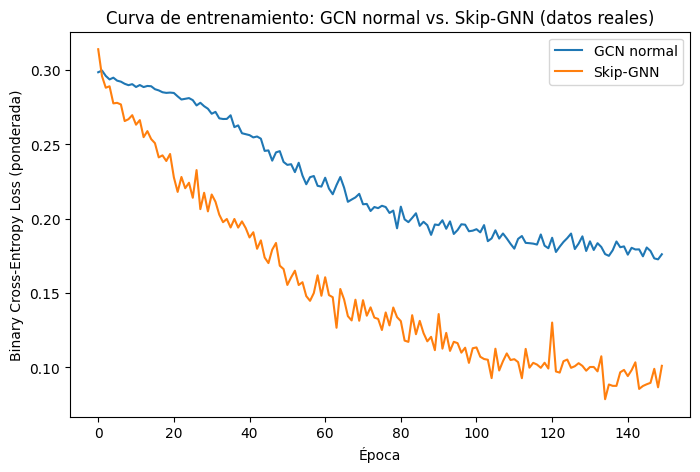

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(loss_gcn, label="GCN normal")
plt.plot(loss_skip, label="Skip-GNN")
plt.xlabel("Época")
plt.ylabel("Binary Cross-Entropy Loss (ponderada)")
plt.title("Curva de entrenamiento: GCN normal vs. Skip-GNN (datos reales)")
plt.legend()
plt.show()

### Resultado

Con estos datos reales, el **Skip-GNN supera tanto a la regresión logística como al GCN normal** en balanced accuracy — el mismo patrón que reporta el paper en sus tres casos de estudio (Tabla 8: Skip-GNN siempre igual o mejor que Logit y que el GCN genérico). Esto sugiere que sí hay señal social real en los datos: saber si los municipios *vecinos* votaron por Duque ayuda a predecir el voto de un municipio, más allá de sus propios atributos.